# Hist2Cell Cell Abundance Visualization Tutorial

## Welcome to the Hist2Cell Visualization Guide! 🔬

This tutorial will guide you through the process of using a pre-trained **Hist2Cell** model to perform inference on spatial transcriptomics data and visualize the predicted cell type abundances directly on histology images.

Whether you're validating model performance or exploring cellular landscapes in new tissues, this guide provides a clear, step-by-step workflow.

## 📋 Table of Contents

1. [**Environment Setup**](#environment-setup)
2. [**Defining and Loading the Hist2Cell Model**](#defining-and-loading-the-hist2cell-model)
3. [**Running Inference on Test Data**](#running-inference-on-test-data)
4. [**Visualizing Predicted Cell Abundances**](#visualizing-predicted-cell-abundances)
5. [**Testing on a Different Donor (Generalization)**](#testing-on-a-different-donor)
6. [**Conclusion and Next Steps**](#conclusion-and-next-steps)

## 🎯 What You'll Learn

By the end of this tutorial, you will:
- ✅ Understand how to load a pre-trained Hist2Cell model
- ✅ Prepare a DataLoader for inference using `NeighborLoader`
- ✅ Run the model to predict cell type abundances from histology data
- ✅ Evaluate model performance using Pearson correlation
- ✅ Create spatial visualization plots that overlay cell abundance predictions on tissue images

### Prerequisites
- You should have a processed dataset in the PyTorch Geometric format, as generated by the `data_preparation_tutorial_new.ipynb`.

<a id='environment-setup'></a>
## ⚙️ Step 1: Environment Setup

First, we'll set up our environment. This involves importing the necessary libraries and configuring the device (GPU or CPU) that PyTorch will use for computations. Using a GPU is highly recommended for faster inference.

In [1]:
import os
import warnings

gpu_list = [0]
gpu_list_str = ",".join(map(str, gpu_list))
os.environ["CUDA_VISIBLE_DEVICES"] = gpu_list_str

import torch

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment setup complete. Using device: {device}")
print("Visible CUDA devices:", torch.cuda.device_count())

Environment setup complete. Using device: cuda
Visible CUDA devices: 1


<a id='defining-and-loading-the-hist2cell-model'></a>
## 🏗️ Step 2: Defining and Loading the Hist2Cell Model

Next, we'll define the architecture of the Hist2Cell model. This code should be identical to the model definition used during training to ensure that the pre-trained weights can be loaded correctly.

### Hist2Cell Architecture Recap

**Hist2Cell** is a Vision Graph-Transformer framework that predicts cell type abundances from histology images. It integrates information at multiple scales:

1.  **Spot-level (Local Features)**: A `ResNet18` backbone extracts features from individual histology image patches.
2.  **Local Neighborhood (Spatial Features)**: A `GATv2Conv` graph neural network layer aggregates information from neighboring spots, capturing the local tissue microenvironment.
3.  **Global Context**: A `VisionTransformer` processes the entire set of spot features from a slide, capturing long-range dependencies and global tissue architecture.
4.  **Multi-scale Fusion**: The model combines features from the spot, local, and global levels to make a final, comprehensive prediction.

In [4]:
# Import necessary modules from PyTorch, PyTorch Geometric, and our custom model files
from torch.nn import Linear
import torch.nn as nn
import torchvision.models as models
from torch_geometric.nn import GATv2Conv, LayerNorm
import sys,os

# Add the parent directory to the system path to allow importing the 'model' module
sys.path.append(os.path.dirname(os.getcwd()))
from model.ViT import Mlp, VisionTransformer


class Hist2Cell(nn.Module):
    """
    Defines the Hist2Cell model architecture, combining a CNN for patch feature
    extraction, a GNN for spatial neighborhood analysis, and a Transformer
    for global context processing.
    """
    def __init__(self, cell_dim=80, vit_depth=3):
        super(Hist2Cell, self).__init__()
        # ------------------- Spot-level Feature Extractor ------------------- #
        # Use a pre-trained ResNet18, removing the final classification layer
        self.resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet18 = torch.nn.Sequential(*list(self.resnet18.children())[:-1])
        
        # ------------------- Model Hyperparameters ------------------- #
        self.embed_dim = 256  # Embedding dimension for GNN and Transformer
        self.head = 8         # Number of attention heads in the GATv2 layer
        self.dropout = 0.3    # Dropout rate for regularization
        
        # ----------------- Local Neighborhood (GNN) Branch ----------------- #
        # GATv2Conv layer to process spatial graph relationships
        self.conv1 = GATv2Conv(in_channels=512, out_channels=int(self.embed_dim/self.head), heads=self.head)
        self.norm1 = LayerNorm(in_channels=self.embed_dim) # Layer normalization
        
        # ------------------- Global Context (Transformer) Branch ------------------- #
        self.cell_transformer = VisionTransformer(num_classes=cell_dim, embed_dim=self.embed_dim, depth=vit_depth,
                                                  mlp_head=True, drop_rate=self.dropout, attn_drop_rate=self.dropout)
        
        # ------------------- Prediction Heads ------------------- #
        # Fully connected layers and MLPs to produce predictions from each branch
        self.spot_fc = Linear(in_features=512, out_features=256)
        self.spot_head = Mlp(in_features=256, hidden_features=512*2, out_features=cell_dim)
        self.local_head = Mlp(in_features=256, hidden_features=512*2, out_features=cell_dim)
        self.fused_head = Mlp(in_features=256, hidden_features=512*2, out_features=cell_dim)
    
    
    def forward(self, x, edge_index):
        """Defines the forward pass of the model."""
        # 1. Get spot-level features from image patches using ResNet18
        x_spot = self.resnet18(x)
        x_spot = x_spot.squeeze() # Remove unnecessary dimensions
        
        # 2. Get local neighborhood features using the GATv2 layer
        x_local = self.conv1(x=x_spot, edge_index=edge_index)
        x_local = self.norm1(x_local)
        
        # Add a batch dimension for the Transformer
        x_local = x_local.unsqueeze(0)
        x_cell = x_local
        
        # 3. Get predictions from each individual branch
        x_spot_processed = self.spot_fc(x_spot)
        cell_predication_spot = self.spot_head(x_spot_processed)
        
        x_local_squeezed = x_local.squeeze(0)
        cell_prediction_local = self.local_head(x_local_squeezed)
        
        # 4. Get global features and predictions from the Vision Transformer
        cell_prediction_global, x_global = self.cell_transformer(x_cell)
        cell_prediction_global = cell_prediction_global.squeeze()
        x_global = x_global.squeeze()
        
        # 5. Create a fused prediction by averaging features from all three levels
        fused_features = (x_spot_processed + x_local_squeezed + x_global) / 3.0
        cell_prediction_fused = self.fused_head(fused_features)
        
        # 6. Average the predictions from all four heads for the final result
        cell_prediction = (cell_predication_spot + cell_prediction_local + cell_prediction_global + cell_prediction_fused) / 4.0
        
        # Apply ReLU activation to ensure non-negative abundance values
        cell_prediction = torch.relu(cell_prediction)
        
        return cell_prediction

### 💾 Loading Pre-trained Weights

Now we'll load the weights from a pre-trained model checkpoint. A checkpoint is a file that saves the state of a model at a specific point during training.

We will use weights from a model trained on the healthy human lung dataset with a **Leave-A50-out** cross-validation strategy. This means the model was trained on data from all donors *except* donor A50. By testing on donor A50's data, we can assess how well the model generalizes to completely unseen tissue samples.

In [5]:
# The donor left out during training
case = "A50"

# Instantiate the Hist2Cell model
model = Hist2Cell(vit_depth=3)

# Load the pre-trained weights from the specified checkpoint file
checkpoint_path = "/home/sjhong/hist2cell/model_weights/humanlung_cell2location_leave_A50_out.pth"
print(f"💾 Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device) # Use map_location to ensure it loads to the correct device
model.load_state_dict(checkpoint)

# Move the model to the selected device (GPU or CPU)
model = model.to(device)

print("✅ Model defined and pre-trained weights loaded successfully!")

💾 Loading checkpoint from: /home/sjhong/hist2cell/model_weights/humanlung_cell2location_leave_A50_out.pth
✅ Model defined and pre-trained weights loaded successfully!


<a id='running-inference-on-test-data'></a>
## 🚀 Step 3: Running Inference on Test Data

With our model loaded, we can now run inference on the test dataset. This involves three main steps:
1.  **Loading the Test Set**: We'll identify the slides belonging to the test set (donor A50).
2.  **Creating a DataLoader**: We'll use PyTorch Geometric's `NeighborLoader` to efficiently load graph data in batches.
3.  **Running the Inference Loop**: We'll iterate through the data, feed it to the model, and collect the predictions.

### Loading the Test Set Definition

The test set for the Leave-A50-out experiment consists of two slides from donor A50. We load their names from a text file.

In [6]:
# Load the list of slide names for the test set
test_slides_path = "./train_test_splits/humanlung_cell2location/test_leave_"+case+".txt"
test_slides = open(test_slides_path).read().split('\n')

print(f"📂 Test slides for donor {case}: {test_slides}")

📂 Test slides for donor A50: ['WSA_LngSP9258463', 'WSA_LngSP9258467']


### Creating a DataLoader and Running Inference

Next, we'll create a `NeighborLoader` to prepare the data for the model. As in the data preparation tutorial, `NeighborLoader` performs subgraph sampling, which is crucial for handling large graphs efficiently.

We then loop through the loader, pass the data to the model, and collect the predicted cell abundances, the ground truth labels, and the spatial coordinates for each spot. Finally, we calculate the Pearson Correlation Coefficient (PCC) between the predictions and the labels to evaluate the model's performance.

In [8]:
from torch_geometric.loader import NeighborLoader
from tqdm import tqdm
import torch_geometric
torch_geometric.typing.WITH_PYG_LIB = False # To handle potential library conflicts
from torch_geometric.data import Batch
import numpy as np
from scipy.stats import pearsonr

# --- DataLoader Configuration ---
hop = 2               # Use a 2-hop neighborhood for subgraph sampling
subgraph_bs = 16      # Subgraph batch size (number of center nodes per batch)

# Load the processed PyG Data objects for each test slide
print("Loading processed data for test slides...")
test_graph_list = list()
for item in test_slides:
    data_path = os.path.join("./example_data/humanlung_cell2location", item+'.pt')
    test_graph_list.append(torch.load(data_path))
# Combine the individual graphs into a single large, disconnected graph
test_dataset = Batch.from_data_list(test_graph_list)
print(f"✅ Loaded and batched {len(test_slides)} slides.")

# Create the NeighborLoader for efficient subgraph sampling during inference
print("Creating NeighborLoader...")
test_loader = NeighborLoader(
    test_dataset,
    num_neighbors=[-1]*hop, # Sample all neighbors at each hop
    batch_size=subgraph_bs,   
    directed=False,           # Treat the graph as undirected
    input_nodes=None,         # Use all nodes as potential centers
    shuffle=False,            # Do not shuffle for inference to maintain order
    num_workers=2,
)

# --- Inference Loop ---
print("🚀 Starting inference...")
with torch.no_grad(): # Disable gradient calculations to save memory and speed up inference
    model.eval() # Set the model to evaluation mode
    test_cell_pred_array = []
    test_cell_label_array = []
    test_cell_pos_array = []
    
    # Iterate over the subgraphs generated by the loader
    for graph in tqdm(test_loader, desc="Processing subgraphs"):
        # Move data to the selected device
        x = graph.x.to(device)
        y = graph.y.to(device)
        pos = graph.pos.to(device)
        edge_index = graph.edge_index.to(device)
        
        # Extract the cell type abundance labels (last 80 values in the 'y' tensor)
        cell_label = y[:, 250:]
        
        # Get model predictions
        cell_pred = model(x=x, edge_index=edge_index)

        # We only need the predictions for the center nodes of each subgraph
        center_num = len(graph.input_id)
        center_cell_label = cell_label[:center_num, :]
        center_cell_pred = cell_pred[:center_num, :]
        center_cell_pos = pos[:center_num, :]
        
        # Append the results to our lists (move back to CPU and convert to numpy)
        test_cell_label_array.append(center_cell_label.squeeze().cpu().detach().numpy())
        test_cell_pred_array.append(center_cell_pred.squeeze().cpu().detach().numpy())
        test_cell_pos_array.append(center_cell_pos.squeeze().cpu().detach().numpy())
        

    # --- Post-processing Results ---
    print("\n🔧 Post-processing results...")
    # Handle cases where the last batch has only one item
    if len(test_cell_pred_array[-1].shape) == 1:
        test_cell_pred_array[-1] = np.expand_dims(test_cell_pred_array[-1], axis=0)
    test_cell_pred_array = np.concatenate(test_cell_pred_array)
    
    if len(test_cell_label_array[-1].shape) == 1:
        test_cell_label_array[-1] = np.expand_dims(test_cell_label_array[-1], axis=0)
    test_cell_label_array = np.concatenate(test_cell_label_array)
    
    if len(test_cell_pos_array[-1].shape) == 1:
        test_cell_pos_array[-1] = np.expand_dims(test_cell_pos_array[-1], axis=0)
    test_cell_pos_array = np.concatenate(test_cell_pos_array)
    
    # --- Evaluation and Storage ---
    # Store predictions and calculate metrics for each slide separately
    Predictions = dict()
    for slide_no in range(len(test_slides)):
        # Find the indices corresponding to the current slide
        indices = np.where(test_dataset.batch.numpy() == slide_no)
        test_cell_pred_array_sub = test_cell_pred_array[indices]
        test_cell_label_array_sub = test_cell_label_array[indices]
        test_cell_pos_array_sub = test_cell_pos_array[indices]
        
        # Calculate the average Pearson Correlation Coefficient (PCC) across all 80 cell types
        test_cell_abundance_all_pearson_average = 0.0
        for i in range(test_cell_pred_array_sub.shape[1]):
            r, _ = pearsonr(test_cell_pred_array_sub[:, i], test_cell_label_array_sub[:, i])
            test_cell_abundance_all_pearson_average += r
        test_cell_abundance_all_pearson_average /= test_cell_pred_array_sub.shape[1]
        
        # Store the results in a dictionary
        Predictions[test_slides[slide_no]] = {
            'cell_abundance_predictions': test_cell_pred_array_sub,
            'cell_abundance_labels': test_cell_label_array_sub,
            'coords': test_cell_pos_array_sub,
        }
        
        print(f"\n📊 Evaluation for slide {test_slides[slide_no]}: Average PCC = {test_cell_abundance_all_pearson_average:.4f}")

Loading processed data for test slides...
✅ Loaded and batched 2 slides.
Creating NeighborLoader...
🚀 Starting inference...


Processing subgraphs: 100%|██████████| 51/51 [00:06<00:00,  7.77it/s]



🔧 Post-processing results...

📊 Evaluation for slide WSA_LngSP9258463: Average PCC = 0.2839

📊 Evaluation for slide WSA_LngSP9258467: Average PCC = 0.3674


### Exploring the Prediction Results

The `Predictions` dictionary now holds the results for each test slide.

In [9]:
# Check the keys of the Predictions dictionary (should be the slide names)
Predictions.keys()

dict_keys(['WSA_LngSP9258463', 'WSA_LngSP9258467'])

For each slide, we have stored the model's predictions, the ground-truth labels, and the spatial coordinates for every spot.

In [10]:
# Check the contents for a single slide
Predictions['WSA_LngSP9258467'].keys()

dict_keys(['cell_abundance_predictions', 'cell_abundance_labels', 'coords'])

<a id='visualizing-predicted-cell-abundances'></a>
## 📊 Step 4: Visualizing Predicted Cell Abundances

Now for the most insightful part: visualizing our model's predictions. We will overlay the predicted cell abundances as a heatmap on top of the low-resolution histology image. This allows us to directly see the spatial distribution of different cell types and validate whether the model is identifying biologically meaningful structures.

These visualizations correspond to those shown in **Figure 3** and **Supplementary Figure 4** of the Hist2Cell paper.

### Defining the Plotting Function

We'll start by creating a helper function, `plot_cell_abundance`, to handle the plotting logic.

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_cell_abundance(img, X, Y, cell_abundance, cell_name, cmap='viridis', s=95):
    """
    Generates a scatter plot of cell abundances overlaid on a histology image.

    Args:
        img (PIL.Image): The background histology image.
        X (array): Array of X coordinates for each spot.
        Y (array): Array of Y coordinates for each spot.
        cell_abundance (array): The predicted abundance values for a specific cell type.
        cell_name (str): The name of the cell type for the plot title.
        cmap (str): The colormap for the scatter plot.
        s (int): The size of the scatter plot points.
    """
    fig, ax = plt.subplots()
    # Display the histology image, flipping it to match the coordinate system
    ax.imshow(img.transpose(Image.FLIP_TOP_BOTTOM).transpose(Image.FLIP_LEFT_RIGHT))

    # Create a scatter plot of the spots. The color of each spot is determined by cell abundance.
    # Coordinates are flipped (img.size - coord) to align with the image's coordinate system.
    sc = ax.scatter(img.size[0] - (X), img.size[1] - (Y),
                    c=cell_abundance,
                    s=s, alpha=0.80, cmap=cmap)

    # Zoom into the tissue area by setting the plot limits
    ax.set_xlim(img.size[0] - (min(X)-50), img.size[0] - (max(X)+50))
    ax.set_ylim(img.size[1] - (min(Y)-50), img.size[1] - (max(Y)+50))
    # Invert the y-axis to match the standard image orientation
    ax.set_ylim(ax.get_ylim()[::-1])

    # Remove axis ticks for a cleaner look
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a color bar to show the scale of cell abundance
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(labelsize=14)
    
    # Set the plot title to the cell type name
    ax.set_title(cell_name, fontsize=16)  
    
    plt.show()

### Visualizing Key Cell Types on Slide `WSA_LngSP9258467`

Now, let's use our function to visualize the abundances of several key cell types for one of the test slides.

In [ ]:
import joblib # For loading the pickled list of cell type names

# Select the slide to visualize
slide = "WSA_LngSP9258467"

# Load the master list of 80 cell type names
cell_types = joblib.load("./example_data/humanlung_cell2location/cell_types.pkl")

# Define a subset of interesting cell types to visualize
visualize_cell_names = ['Ciliated', 'Basal', 'AT1', 'AT2', 'Chondrocyte', 'T_reg', 'Suprabasal', 'SMG_Mucous', 'B_naive', 'Fibro_adventitial', 'Fibro_peribronchial']

# Get the predictions and coordinates for the selected slide
# Clip predictions at 0 to remove any small negative values from the model output
hist2cell_abundances = np.clip(Predictions[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
coordinates = Predictions[slide]['coords']

# The low-resolution image coordinates are 1/4 of the full-resolution coordinates
X = coordinates[:, 0] / 4
Y = coordinates[:, 1] / 4

# Load the corresponding low-resolution histology image
jpg_path = './example_data/humanlung_cell2location/'+slide+'_low_res.jpg'
img = Image.open(jpg_path)


# Loop through the selected cell types and generate a plot for each one
print(f"🖼️  Generating abundance plots for slide {slide}...")
for i in tqdm(range(len(visualize_cell_names)), desc="Plotting cell types"):
    cell_name = visualize_cell_names[i]
    # Find the index of the current cell type
    cell_idx = cell_types.index(cell_name)
    # Call our plotting function
    plot_cell_abundance(img, X, Y, hist2cell_abundances[:, cell_idx], cell_name, cmap='viridis')

FileNotFoundError: [Errno 2] No such file or directory: '/home/sjhong/example_data/humanlung_cell2location/WSA_LngSP9258467_low_res.jpg'

<a id='testing-on-a-different-donor'></a>
## 🌍 Step 5: Testing on a Different Donor (Generalization)

To further demonstrate the capabilities of Hist2Cell, we will repeat the process for a different donor and slide. This example corresponds to the visualizations in **Figure 2** of the paper.

We will load a different set of pre-trained weights, this time from a **Leave-A37-out** experiment, and visualize the results on a slide from donor A37.

In [10]:
# Define the new case and load the corresponding model checkpoint
case = "A37"
print(f"--- Starting new case: {case} ---")

model = Hist2Cell(vit_depth=3)
checkpoint = torch.load("../model_weights/humanlung_cell2location_leave_"+case+"_out.pth", map_location=device)
model.load_state_dict(checkpoint)
model = model.to(device)

print("✅ Model for new case loaded.")

--- Starting new case: A37 ---
✅ Model for new case loaded.


In [11]:
# Load the test slides for the A37-out experiment
test_slides = open("../train_test_splits/humanlung_cell2location/test_leave_"+case+".txt").read().split('\n')
print(f"📂 Test slides for donor {case}: {test_slides}")

📂 Test slides for donor A37: ['WSA_LngSP9258464', 'WSA_LngSP9258468', 'WSA_LngSP10193347', 'WSA_LngSP10193348']


In [16]:
# This entire block repeats the inference and evaluation process for the new case (A37).
# The logic is identical to Step 3.

# --- DataLoader Configuration ---
hop = 2
subgraph_bs = 16
test_graph_list = list()
for item in test_slides:
    test_graph_list.append(torch.load(os.path.join("./example_data/humanlung_cell2location", item+'.pt')))
test_dataset = Batch.from_data_list(test_graph_list)

# --- DataLoader Creation ---
test_loader = NeighborLoader(
    test_dataset,
    num_neighbors=[-1]*hop,
    batch_size=subgraph_bs,
    directed=False,
    input_nodes=None,
    shuffle=False,
    num_workers=2,
)

# --- Inference Loop ---
print(f"🚀 Starting inference for case {case}...")
with torch.no_grad():
    model.eval()
    test_cell_pred_array = []
    test_cell_label_array = []
    test_cell_pos_array = []
    for graph in tqdm(test_loader, desc="Processing subgraphs"):
        x = graph.x.to(device)
        y = graph.y.to(device)
        pos = graph.pos.to(device)
        edge_index = graph.edge_index.to(device)
        cell_label = y[:, 250:]
        cell_pred = model(x=x, edge_index=edge_index)

        center_num = len(graph.input_id)
        center_cell_label = cell_label[:center_num, :]
        center_cell_pred = cell_pred[:center_num, :]
        center_cell_pos = pos[:center_num, :]
        
        test_cell_label_array.append(center_cell_label.squeeze().cpu().detach().numpy())
        test_cell_pred_array.append(center_cell_pred.squeeze().cpu().detach().numpy())
        test_cell_pos_array.append(center_cell_pos.squeeze().cpu().detach().numpy())
        

    # --- Post-processing ---
    if len(test_cell_pred_array[-1].shape) == 1:
        test_cell_pred_array[-1] = np.expand_dims(test_cell_pred_array[-1], axis=0)
    test_cell_pred_array = np.concatenate(test_cell_pred_array)
    if len(test_cell_label_array[-1].shape) == 1:
        test_cell_label_array[-1] = np.expand_dims(test_cell_label_array[-1], axis=0)
    test_cell_label_array = np.concatenate(test_cell_label_array)
    if len(test_cell_pos_array[-1].shape) == 1:
        test_cell_pos_array[-1] = np.expand_dims(test_cell_pos_array[-1], axis=0)
    test_cell_pos_array = np.concatenate(test_cell_pos_array)
    

    # --- Evaluation and Storage ---
    Predictions = dict()
    for slide_no in range(len(test_slides)):
        indices = np.where(test_dataset.batch.numpy() == slide_no)
        test_cell_pred_array_sub = test_cell_pred_array[indices]
        test_cell_label_array_sub = test_cell_label_array[indices]
        test_cell_pos_arraay_sub = test_cell_pos_array[indices]
        
        test_cell_abundance_all_pearson_average = 0.0
        for i in range(test_cell_pred_array_sub.shape[1]):
            r, p = pearsonr(test_cell_pred_array_sub[:, i], test_cell_label_array_sub[:, i])
            test_cell_abundance_all_pearson_average = test_cell_abundance_all_pearson_average + r
        test_cell_abundance_all_pearson_average = test_cell_abundance_all_pearson_average / test_cell_pred_array_sub.shape[1]
        
        Predictions[test_slides[slide_no]] = {
            'cell_abundance_predictions': test_cell_pred_array_sub,
            'cell_abundance_labels': test_cell_label_array_sub,
            'coords': test_cell_pos_arraay_sub,
        }
        
        print(f"\n📊 Evaluation for slide {test_slides[slide_no]}: Average PCC = {test_cell_abundance_all_pearson_average:.4f}")

🚀 Starting inference for case A50...


Processing subgraphs: 100%|██████████| 51/51 [00:04<00:00, 10.41it/s]


📊 Evaluation for slide WSA_LngSP9258463: Average PCC = 0.2839

📊 Evaluation for slide WSA_LngSP9258467: Average PCC = 0.3674


### Visualizing Key Cell Types on Slide `WSA_LngSP9258464`

In [21]:
# This block repeats the visualization process for the new case.
# The logic is identical to Step 4.

import joblib
from tqdm import tqdm

# Select the slide to visualize from the new donor
slide = "WSA_LngSP9258463"

# Load cell type names
cell_types = joblib.load("./example_data/humanlung_cell2location/cell_types.pkl")
# Define cell types relevant for this slide/figure
visualize_cell_names = ['Ciliated', 'SMG_Serous',  'B_plasma_IgA']


In [22]:
Predictions.keys()

dict_keys(['WSA_LngSP9258463', 'WSA_LngSP9258467'])

In [25]:

# Get predictions and coordinates
hist2cell_abundances = np.clip(Predictions[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
coordinates = Predictions[slide]['coords']
X = coordinates[:, 0] / 4
Y = coordinates[:, 1] / 4

In [27]:
X.shape, Y.shape

((386,), (386,))

🖼️  Generating abundance plots for slide WSA_LngSP9258463...


Plotting cell types:   0%|          | 0/3 [00:00<?, ?it/s]

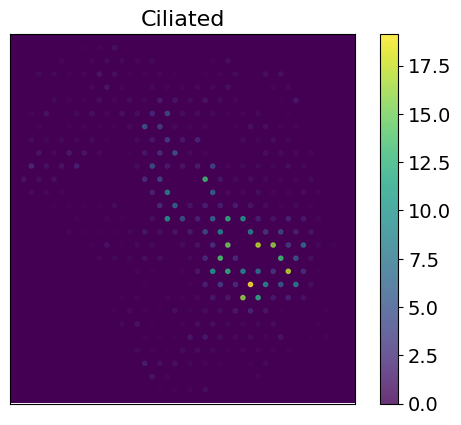

Plotting cell types:  33%|███▎      | 1/3 [00:00<00:00,  3.14it/s]

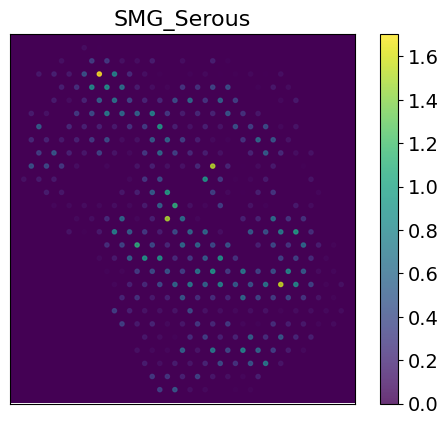

Plotting cell types:  67%|██████▋   | 2/3 [00:00<00:00,  3.65it/s]

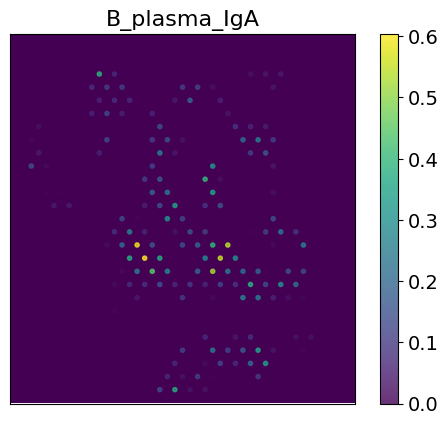

Plotting cell types: 100%|██████████| 3/3 [00:00<00:00,  3.79it/s]


In [30]:
H = int(Y.max()) + 256
W = int(X.max()) + 256

img = Image.new('L', (W, H), color=255)  # 흰색 (grayscale)

# Generate plots
# Note: The scatter point size 's' is reduced to 9 for better visibility on this slide
print(f"🖼️  Generating abundance plots for slide {slide}...")
for i in tqdm(range(len(visualize_cell_names)), desc="Plotting cell types"):
    cell_name = visualize_cell_names[i]
    cell_idx = cell_types.index(cell_name)
    plot_cell_abundance(img, X, Y, hist2cell_abundances[:, cell_idx], cell_name, cmap='viridis', s=9)

<a id='conclusion-and-next-steps'></a>
# 🎉 Tutorial Complete! You've Visualized Cellular Landscapes

## 📋 Summary of What We've Accomplished

Congratulations! You've successfully used Hist2Cell to predict and visualize the spatial organization of cell types from histology images. 

We have covered the entire inference and visualization workflow:
1.  **✅ Model Loading**: Loaded a pre-trained Hist2Cell model and its weights.
2.  **✅ Data Handling**: Used `NeighborLoader` to prepare unseen data for inference.
3.  **✅ Inference**: Ran the model to generate cell abundance predictions for every spot.
4.  **✅ Evaluation**: Quantified model performance using the Pearson correlation coefficient.
5.  **✅ Visualization**: Created informative plots showing the spatial distribution of various cell types on the tissue slide.

## 🔄 Next Steps in Your Hist2Cell Journey

Now that you can generate and visualize predictions, explore the other analysis tutorials in `../tutorial_analysis_evaluation/` to dive deeper:

- **Cell Co-localization**: Analyze which cell types tend to appear near each other.
- **Super-resolution**: Generate high-resolution cell abundance maps.
- **Key Cell Evaluation**: Perform more detailed evaluations on specific cell types of interest.

You can also adapt this notebook to run inference and visualization on your own processed data. Simply point the script to your model checkpoint and your processed `.pt` files.

---

*Happy analyzing! 🧬✨*